# Analiza zamówień e-commerce
Czyszczenie i analiza brudnego zbioru danych

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from datetime import datetime, timedelta

# ten kod generuje plik z brudnymi danymi - trzeba go odpalić tylko raz
# random_seed ustawiam na 42 zeby za kazdym razem wychodzily te same dane
np.random.seed(42)

n = 500
klienci = ["Anna Kowalska", "  Jan Nowak", "Anna Kowalska", "PIOTR WIŚNIEWSKI",
           "katarzyna lewandowska", "Tomasz Zieliński ", "Marta Wójcik",
           "anna kowalska ", "Krzysztof Kamiński", " Magdalena Dąbrowska"]
produkty = ["Laptop", "Mysz", "Klawiatura", "Monitor", "laptop", "MYSZ",
            "Słuchawki", "Pendrive", "monitor", "Webcam"]
kategorie = ["Elektronika", "elektronika", "ELEKTRONIKA", "Akcesoria",
             "akcesoria", "Akcesoria "]
miasta = ["Warszawa", "Kraków", "warszawa", "Gdańsk", "WROCŁAW",
          "Poznań", "Łódź ", " Warszawa", "kraków"]

start_date = datetime(2025, 1, 1)
daty_iso = [(start_date + timedelta(days=int(d))).strftime("%Y-%m-%d")
            for d in np.random.randint(0, 300, n // 2)]
daty_pl = [(start_date + timedelta(days=int(d))).strftime("%d.%m.%Y")
           for d in np.random.randint(0, 300, n // 2)]
daty = daty_iso + daty_pl
np.random.shuffle(daty)

df_raw = pd.DataFrame({
    "order_id": range(1001, 1001 + n),
    "klient": np.random.choice(klienci, n),
    "produkt": np.random.choice(produkty, n),
    "kategoria": np.random.choice(kategorie, n),
    "miasto": np.random.choice(miasta, n),
    "ilosc": np.random.choice([1, 2, 3, 5, -1, 0], n, p=[0.5, 0.2, 0.15, 0.1, 0.025, 0.025]),
    "cena_jednostkowa": np.random.choice(
        ["199.99", "299,99", "1 499.00", "89.50", "2999", "399.00 zł", None, "abc"], n
    ),
    "data_zamowienia": daty,
    "email": np.random.choice(
        ["anna@gmail.com", "JAN@WP.PL", "piotr.w@onet", "marta@gmail.com",
         "tomasz@interia.pl", None, "krzysztof.k@gmail.com", "brak"], n
    )
})

for col in ["miasto", "kategoria", "data_zamowienia"]:
    df_raw.loc[df_raw.sample(frac=0.05, random_state=1).index, col] = np.nan

df_raw = pd.concat([df_raw, df_raw.sample(20, random_state=2)], ignore_index=True)
df_raw.to_csv("zamowienia_messy.csv", index=False)
print(f"Wygenerowano plik 'zamowienia_messy.csv' — {len(df_raw)} wierszy")

Wygenerowano plik 'zamowienia_messy.csv' — 520 wierszy


## Część 1: Eksploracja

In [13]:
df = pd.read_csv("zamowienia_messy.csv")

print("=== shape ===")
print(df.shape)

print("\n=== info ===")
df.info()

=== shape ===
(520, 9)

=== info ===
<class 'pandas.DataFrame'>
RangeIndex: 520 entries, 0 to 519
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   order_id          520 non-null    int64
 1   klient            520 non-null    str  
 2   produkt           520 non-null    str  
 3   kategoria         495 non-null    str  
 4   miasto            495 non-null    str  
 5   ilosc             520 non-null    int64
 6   cena_jednostkowa  457 non-null    str  
 7   data_zamowienia   495 non-null    str  
 8   email             457 non-null    str  
dtypes: int64(2), str(7)
memory usage: 36.7 KB


In [14]:
print("=== describe ===")
df.describe(include="all")

=== describe ===


,order_id,klient,produkt,kategoria,miasto,ilosc,cena_jednostkowa,data_zamowienia,email
count,520.000000,520,520,495,495,520.000000,457,495,457
unique,NaN,9,10,6,9,NaN,7,313,7
top,NaN,Anna Kowalska,Mysz,Akcesoria,warszawa,NaN,199.99,2025-04-09,anna@gmail.com
freq,NaN,107,62,90,61,NaN,78,5,77
mean,1252.296154,NaN,NaN,NaN,NaN,1.678846,NaN,NaN,NaN
std,144.135844,NaN,NaN,NaN,NaN,1.303151,NaN,NaN,NaN
min,1001.000000,NaN,NaN,NaN,NaN,-1.000000,NaN,NaN,NaN
25%,1129.750000,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,NaN
50%,1253.500000,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,NaN
75%,1376.250000,NaN,NaN,NaN,NaN,2.000000,NaN,NaN,NaN


In [15]:
print("=== brakujące wartości ===")
print(df.isnull().sum())

print("\n=== unikalne wartości w kolumnie klient ===")
print(df["klient"].value_counts())

print("\n=== unikalne wartości w kolumnie kategoria ===")
print(df["kategoria"].value_counts())

# znalazłem 6 problemów w danych:
# 1. duplikaty wierszy (dodano 20 kopii)
# 2. niejednolita wielkość liter i białe znaki (np. 'anna kowalska ', 'PIOTR WIŚNIEWSKI')
# 3. dwa formaty dat: ISO (2025-01-15) i polski (15.01.2025)
# 4. cena_jednostkowa jako tekst z różnymi formatami: przecinki, spacje, 'zł', 'abc'
# 5. ujemne i zerowe ilości (-1, 0)
# 6. braki w kolumnach: miasto, kategoria, data_zamowienia, email, cena_jednostkowa

=== brakujące wartości ===
order_id             0
klient               0
produkt              0
kategoria           25
miasto              25
ilosc                0
cena_jednostkowa    63
data_zamowienia     25
email               63
dtype: int64

=== unikalne wartości w kolumnie klient ===
klient
Anna Kowalska            107
anna kowalska             58
Krzysztof Kamiński        56
katarzyna lewandowska     55
Marta Wójcik              55
 Magdalena Dąbrowska      54
  Jan Nowak               53
Tomasz Zieliński          45
PIOTR WIŚNIEWSKI          37
Name: count, dtype: int64

=== unikalne wartości w kolumnie kategoria ===
kategoria
Akcesoria      90
akcesoria      90
elektronika    87
Akcesoria      82
Elektronika    80
ELEKTRONIKA    66
Name: count, dtype: int64


## Część 2: Czyszczenie

In [16]:
# usuwam duplikaty - było ich 20 bo tak zrobił skrypt generujący dane
df = df.drop_duplicates()
print(f"Po usunięciu duplikatów: {len(df)} wierszy")

# strip usuwa spacje z boków, title() robi pierwszą literę wielką - np. "warszawa" -> "Warszawa"
for col in ["klient", "produkt", "kategoria", "miasto"]:
    df[col] = df[col].str.strip().str.title()

# daty sa w dwóch formatach więc probuje najpierw jeden potem drugi
def parse_date(val):
    if pd.isna(val):
        return pd.NaT
    try:
        return pd.to_datetime(val, format="%Y-%m-%d")
    except:
        try:
            return pd.to_datetime(val, format="%d.%m.%Y")
        except:
            return pd.NaT

df["data_zamowienia"] = df["data_zamowienia"].apply(parse_date)

# ceny sa jako tekst więc trzeba je posprzatac - usuwam spacje, zamieniam przecinki na kropki itd. 'zł'
def parse_price(val):
    if pd.isna(val):
        return np.nan
    val = str(val).replace(" ", "").replace(",", ".").replace("zł", "")
    try:
        return float(val)
    except:
        return np.nan

df["cena_jednostkowa"] = df["cena_jednostkowa"].apply(parse_price)

# jak nie ma ceny albo daty to ten wiersz jest bezużyteczny - usuwam
df = df.dropna(subset=["cena_jednostkowa", "data_zamowienia"])

# reszta braków wypelniam domyślnymi wartościami zamiast usuwać
df["miasto"] = df["miasto"].fillna("Unknown")
df["kategoria"] = df["kategoria"].fillna("Unknown")
df["email"] = df["email"].fillna("brak_emaila")

# zamówienie na -1 sztuk nie ma sensu więc to usuwam
df = df[df["ilosc"] > 0]

print(f"Po czyszczeniu: {len(df)} wierszy")
df.head()

Po usunięciu duplikatów: 500 wierszy
Po czyszczeniu: 339 wierszy


,order_id,klient,produkt,kategoria,miasto,ilosc,cena_jednostkowa,data_zamowienia,email
0,1001,Jan Nowak,Mysz,Akcesoria,Kraków,2,199.99,2025-06-13,brak_emaila
1,1002,Anna Kowalska,Monitor,Elektronika,Kraków,1,399.00,2025-04-09,marta@gmail.com
4,1005,Piotr Wiśniewski,Mysz,Elektronika,Gdańsk,1,1499.00,2025-02-05,anna@gmail.com
5,1006,Magdalena Dąbrowska,Laptop,Akcesoria,Warszawa,1,299.99,2025-07-04,tomasz@interia.pl
6,1007,Katarzyna Lewandowska,Monitor,Akcesoria,Łódź,1,1499.00,2025-10-11,marta@gmail.com


## Część 3: Transformacje

In [17]:
# obliczam wartość każdego zamówienia = ile sztuk * cena jednej
df["wartosc_zamowienia"] = df["ilosc"] * df["cena_jednostkowa"]

# wyciągam rok, miesiąc i dzień tygodnia z daty - przyda się do analizy
df["rok"] = df["data_zamowienia"].dt.year
df["miesiac"] = df["data_zamowienia"].dt.month
df["nazwa_dnia"] = df["data_zamowienia"].dt.day_name()

# regex sprawdza czy email ma format cos@cos.cos - jak nie to False
email_pattern = r"^[\w.+-]+@[\w-]+\.[a-zA-Z]{2,}$"
df["email_poprawny"] = df["email"].apply(
    lambda x: bool(re.match(email_pattern, str(x)))
)

df[["klient", "email", "email_poprawny", "wartosc_zamowienia", "rok", "miesiac", "nazwa_dnia"]].head(10)

,klient,email,email_poprawny,wartosc_zamowienia,rok,miesiac,nazwa_dnia
0,Jan Nowak,brak_emaila,False,399.98,2025,6,Friday
1,Anna Kowalska,marta@gmail.com,True,399.00,2025,4,Wednesday
4,Piotr Wiśniewski,anna@gmail.com,True,1499.00,2025,2,Wednesday
5,Magdalena Dąbrowska,tomasz@interia.pl,True,299.99,2025,7,Friday
6,Katarzyna Lewandowska,marta@gmail.com,True,1499.00,2025,10,Saturday
7,Piotr Wiśniewski,anna@gmail.com,True,599.97,2025,5,Saturday
9,Anna Kowalska,tomasz@interia.pl,True,199.99,2025,5,Saturday
10,Tomasz Zieliński,marta@gmail.com,True,2999.00,2025,9,Sunday
12,Anna Kowalska,anna@gmail.com,True,399.98,2025,5,Friday
13,Marta Wójcik,anna@gmail.com,True,2998.00,2025,6,Sunday


## Część 4: Analiza

In [18]:
# grupuję po miesiącu i sumuję wartości
print("=== Łączna wartość zamówień miesięcznie ===")
miesiace = df.groupby("miesiac")["wartosc_zamowienia"].sum().sort_index()
print(miesiace)

=== Łączna wartość zamówień miesięcznie ===
miesiac
1     37455.81
2     76368.24
3     66899.90
4     75426.25
5     39159.21
6     65508.21
7     29248.24
8     59905.68
9     68743.34
10    38875.80
Name: wartosc_zamowienia, dtype: float64


In [19]:
# sortuję malejąco i biorę pierwszych 5
print("=== Top 5 klientów wg wartości zamówień ===")
top5 = df.groupby("klient")["wartosc_zamowienia"].sum().sort_values(ascending=False).head(5)
print(top5)

=== Top 5 klientów wg wartości zamówień ===
klient
Anna Kowalska            203426.36
Krzysztof Kamiński        84677.82
Katarzyna Lewandowska     55083.04
Marta Wójcik              51070.25
Magdalena Dąbrowska       49000.33
Name: wartosc_zamowienia, dtype: float64


In [20]:
# średnia wartość zamówienia per kategoria
print("=== Średnia wartość zamówienia na kategorię ===")
srednia = df.groupby("kategoria")["wartosc_zamowienia"].mean().sort_values(ascending=False)
print(srednia)

=== Średnia wartość zamówienia na kategorię ===
kategoria
Akcesoria      1671.656796
Elektronika    1614.055696
Name: wartosc_zamowienia, dtype: float64


## Część 5: Wizualizacja

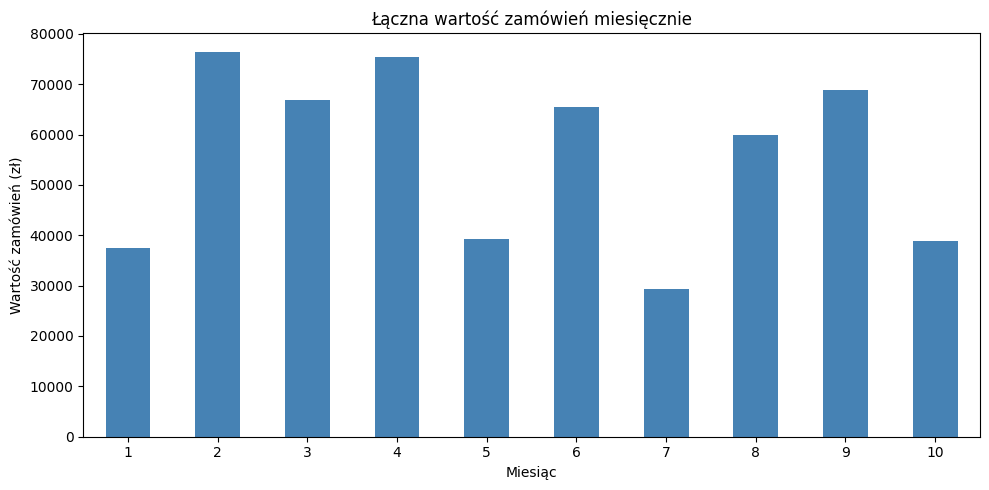

In [21]:
# robię wykres słupkowy - każdy słupek to jeden miesiąc
plt.figure(figsize=(10, 5))
miesiace.plot(kind="bar", color="steelblue")
plt.title("Łączna wartość zamówień miesięcznie")
plt.xlabel("Miesiąc")
plt.ylabel("Wartość zamówień (zł)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Część 6: Zapis

In [22]:
df.to_csv("zamowienia_clean.csv", index=False)
print(f"Zapisano zamowienia_clean.csv — {len(df)} wierszy")

Zapisano zamowienia_clean.csv — 339 wierszy
